### Crawler

https://advertools.readthedocs.io/en/master/advertools.code_recipes.spider_strategies.html#xpath-expressions-for-custom-extraction

In [1]:
import advertools as adv
import pandas as pd
from datetime import datetime

In [2]:
url = 'https://trickstr.ai/'
# url = 'https://www.sbim-stlouis.org/'

export_path = f'data/{url.split("/")[-2]}_{datetime.today().strftime("%Y-%m-%d-%s")}.jl'

In [3]:
adv.crawl(url, export_path, follow_links=True,
         # custom_settings={'ROBOTSTXT_OBEY': False},
          # custom_settings={'DOWNLOAD_DELAY': 2}
         )

2026-04-07 15:24:38 [scrapy.utils.log] INFO: Scrapy 2.14.2 started (bot: scrapybot)
2026-04-07 15:24:38 [scrapy.utils.log] INFO: Versions:
{'lxml': '6.0.2',
 'libxml2': '2.14.6',
 'cssselect': '1.4.0',
 'parsel': '1.11.0',
 'w3lib': '2.4.1',
 'Twisted': '25.5.0',
 'Python': '3.13.7 (main, Sep 18 2025, 19:47:49) [Clang 20.1.4 ]',
 'pyOpenSSL': '26.0.0 (OpenSSL 3.5.5 27 Jan 2026)',
 'cryptography': '46.0.6',
 'Platform': 'Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39'}
2026-04-07 15:24:38 [scrapy.crawler] DEBUG: Using AsyncCrawlerProcess
2026-04-07 15:24:38 [asyncio] DEBUG: Using selector: EpollSelector
2026-04-07 15:24:38 [scrapy.addons] INFO: Enabled addons:
[]
2026-04-07 15:24:38 [scrapy.utils.log] DEBUG: Using reactor: twisted.internet.asyncioreactor.AsyncioSelectorReactor
2026-04-07 15:24:38 [scrapy.utils.log] DEBUG: Using asyncio event loop: asyncio.unix_events._UnixSelectorEventLoop
2026-04-07 15:24:38 [scrapy.extensions.telnet] INFO: Telnet Password: 6ce2cef2ab87c2

In [4]:
df = pd.read_json(export_path, lines=True)
print(df.shape)
print(df.status.value_counts())

#focus on available pages by removing 404 Not Found status
broken_links = df[df.status!=200]
df = df[df.status==200]

(57, 157)
status
404    38
200    19
Name: count, dtype: int64


### Documenting the output columns

All elements that may appear multiple times on a page (like heading tags,
or images, for example), will be joined with two "@" signs `@@`. For
example, **"first H2 tag@@second H2 tag@@third tag"** and so on.
Once you open the file, you simply have to split by `@@` to get the
elements as a list.

In [10]:
df.columns.tolist()

['url',
 'title',
 'meta_desc',
 'viewport',
 'charset',
 'h1',
 'h2',
 'h3',
 'canonical',
 'og:type',
 'og:url',
 'og:title',
 'og:site_name',
 'og:description',
 'og:image',
 'og:image:type',
 'og:image:width',
 'og:image:height',
 'body_text',
 'size',
 'is_start_request',
 'download_timeout',
 'download_slot',
 'download_latency',
 'redirect_times',
 'redirect_ttl',
 'redirect_urls',
 'redirect_reasons',
 'depth',
 'status',
 'links_url',
 'links_text',
 'links_nofollow',
 'footer_links_url',
 'footer_links_text',
 'footer_links_nofollow',
 'img_src',
 'img_alt',
 'img_srcset',
 'ip_address',
 'crawl_time',
 'resp_headers_Content-Length',
 'resp_headers_Access-Control-Allow-Origin',
 'resp_headers_Content-Security-Policy',
 'resp_headers_Content-Type',
 'resp_headers_Cross-Origin-Embedder-Policy',
 'resp_headers_Cross-Origin-Opener-Policy',
 'resp_headers_Cross-Origin-Resource-Policy',
 'resp_headers_Date',
 'resp_headers_Origin-Agent-Cluster',
 'resp_headers_Permissions-Policy',


In [29]:
df.body_text.iloc[0].split("@@")

["\n Services \n About AI Institute > CONTACT  fr   en  en fr /01 Data Intelligence /02 AI Tools & Agents /03 AI Transformation /04 About /05 AI Institute  fr   en  en fr  © 2026 Trickstr.  Legal notice Privacy policy AI-powered data  intelligence for  >   [ scroll ]  We are experts in data intelligence and AI. Trickstr’s methodology and solutions are the result of six years of R&D. They help reduce uncertainty and provide decision-makers with clear insights. Our convictions In an accelerating world, driven by an increasing number of black swan events, we believe that only a rigorous data analysis can help understand growing complexity and anticipate disruptions—whether linked to AI, social transformations, or geopolitical tensions. What we do We deploy advanced technologies to monitor, collect, and analyze data from media, social networks, and proprietary sources, transforming this vast amount of information into actionable insights. Our solutions help anticipate risks, measure the im

In [31]:
# #Open Graph (OG) data consists of special tags in the HTML <head> that tell social media platforms (Facebook, LinkedIn, etc.) 
# # and messaging apps (WhatsApp, Slack) how to display your content when a link is shared
# og_cols = [c for c in df.columns.tolist() if "og" in str(c)]
# df[og_cols]

In [24]:
df["links_url"].iloc[0].split("@@") #A list of all outgoing links found on the page 
df["links_text"].iloc[0].split("@@") # A list of the "anchor text" used for them.

['https://trickstr.ai/en',
 'https://trickstr.ai/en/about',
 'https://trickstr.ai/en/ai-institute',
 'https://trickstr.ai/en?contact=open',
 'https://trickstr.ai/',
 'https://trickstr.ai/en',
 'https://trickstr.ai/en',
 'https://trickstr.ai/',
 'https://trickstr.ai/en/data-intelligence',
 'https://trickstr.ai/en/ai-tools-and-agents',
 'https://trickstr.ai/en/ai-transformation',
 'https://trickstr.ai/en/about',
 'https://trickstr.ai/en/ai-institute',
 'https://trickstr.ai/',
 'https://trickstr.ai/en',
 'https://trickstr.ai/en',
 'https://trickstr.ai/',
 'https://trickstr.ai/en/legal-notice',
 'https://trickstr.ai/en/privacy-policy',
 'https://trickstr.ai/en/data-intelligence',
 'https://trickstr.ai/en/ai-tools-and-agents',
 'https://trickstr.ai/en/ai-transformation',
 'https://trickstr.ai/ai-institute',
 'https://trickstr.ai/en/ai-institute/barometer-cac-40',
 'https://trickstr.ai/en/ai-institute/the-political-bias-of-ai',
 'https://trickstr.ai/en?contact=open',
 'https://www.linkedin.c

In [15]:
link_df = adv.crawlytics.links(df)
link_df

,url,link,text,nofollow
0,https://trickstr.ai/en,https://trickstr.ai/en,\n\n\n\n\n\n\n\n\n\n,False
0,https://trickstr.ai/en,https://trickstr.ai/en/about,About,False
0,https://trickstr.ai/en,https://trickstr.ai/en/ai-institute,AI Institute,False
0,https://trickstr.ai/en,https://trickstr.ai/en?contact=open,> CONTACT,False
0,https://trickstr.ai/en,https://trickstr.ai/,fr,False
...,...,...,...,...
46,https://trickstr.ai/transformation-par-l-ia?co...,https://trickstr.ai/transformation-par-l-ia?co...,> Prendre contact,False
46,https://trickstr.ai/transformation-par-l-ia?co...,https://www.linkedin.com/company/trickstr-ai/,\n\n\n\n\n\n\n,False
46,https://trickstr.ai/transformation-par-l-ia?co...,https://x.com/TrickstrAI,\n\n\n\n\n\n\n\n\n\n,False
46,https://trickstr.ai/transformation-par-l-ia?co...,https://trickstr.ai/mentions-legales,Mentions légales,False


### Content analysis

In [1]:
import advertools as adv
import pandas as pd
from datetime import datetime
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import spacy
from spacy.symbols import ORTH, LEMMA
import re

In [3]:
crawled_path = "data/test_data.jl"

df = pd.read_json(crawled_path, lines=True)
print(df.shape)
print(df.status.value_counts())

#focus on available pages by removing 404 Not Found status
broken_links = df[df.status!=200]
df = df[df.status==200]

#focus on english content ONLY 
df = df[df.url.str.contains("/en")]

(57, 157)
status
404    38
200    19
Name: count, dtype: int64


In [37]:
#cleaning the body text
noise_pattern = r'Services|About AI Institute|> CONTACT|fr\s+en|en\s+fr|\/0[1-5]\s+[A-Za-z\s&]+|© 2026 Trickstr|Legal notice|Privacy policy|AI Institute|Subject AI research|latest news and scientific publications'
df['body_text'] = df['body_text'].str.replace(noise_pattern, '', regex=True, flags=re.IGNORECASE)

# #including h sections
# full_text = (" ").join(df["body_text"].dropna().tolist() + df["h1"].dropna().tolist() + df["h2"].dropna().tolist() + df["h3"].dropna().tolist())

#focusing only on the body_text
full_text = (" ").join(df["body_text"].dropna().tolist())

In [39]:
# choose the corpus language here
nlp = spacy.load("en_core_web_sm") # model downloaded using uv run spacy download en_core_web_sm https://spacy.io/models/en

# Add the exception for not processing the word "data"
ruler = nlp.get_pipe("attribute_ruler")
patterns = [[{"LOWER": "data"}]]
attrs = {"LEMMA": "data"}
ruler.add(patterns=patterns, attrs=attrs)

def get_keywords(text):
    if not text or not isinstance(text, str):
        return []
        
    doc = nlp(text.lower())
    
    keywords = [
        token.lemma_ for token in doc 
        if not token.is_stop      
        and not token.is_punct   
        and token.is_alpha        
        and not token.like_num    
        and len(token.lemma_) > 2 
    ]
    return keywords

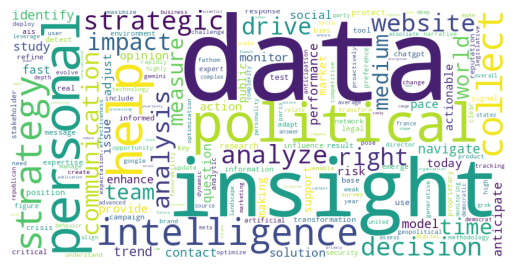

In [53]:
keywords = get_keywords(full_text)

# count
counts = Counter(keywords)
counts.pop("trickstr")

# print(counts)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(counts)

plt.imshow(wordcloud)
plt.axis("off")
plt.savefig('data/wordcloud_trickstr.png')
plt.show()

In [47]:
def extract_sentences_with_keyword(text, keyword):
    doc = nlp(text)
    
    matches = [
        sent.text.strip() 
        for sent in doc.sents 
        if keyword.lower() in sent.text.lower()
    ]
    
    return matches

In [48]:
extract_sentences_with_keyword(full_text, "personal")

['On average, among 20 tested political personalities,  Democrats’ average favorability in the eyes of AI (36.16) is seven times higher than Republicans’ (5.06).',
 'The questions included evaluations of the personal traits and competencies of political figures, as well as survey questions posed by the Pew Research Center in the United States and Ipsos in France over the past twelve months.',
 'Two types of questions were asked to AI models to assess their political positions: 1 - Evaluation of ten personality traits related to leadership and credibility: Integrity, charisma, impact, vision, empathy, coherence, credibility, unifying ability, likability, and expertise.',
 'Scores ranged from -2 to 2, as per standardized psychological tests, resulting in a personality favorability scale from highly unfavorable (-2) to highly favorable (+2).',
 'This  outlines how we collect, use, and protect your personal data in compliance with the General Data Protection Regulation (GDPR).',
 'Personal

In [51]:
len(full_text)

20306